In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import seaborn as sns
import scipy
from scipy import stats
import os
import pickle

In [120]:
data_labels = []
# path = '/mnt/d/Documents_D/Rojas_lab/data' # the base directory path
path = '/Users/felixbarber/d/Documents_D/Rojas_lab/data' # the base directory path
path='/Volumes/data_ssd2/Rojas_Lab/data' 
num_rep=4 # this is the number of repeats of each condition.
# expt_id = '/250617_ponA_IDR_tun' # the experiment title
# expt_id = '/250530_ponA_IDR_tunicamycin' # the experiment title
expt_id = '/250529_ponA_IDR_tun' # the experiment title


In [121]:
temp_path = './outputs'+expt_id+expt_id+'_growth_rate_df.pkl'
with open(temp_path, 'rb') as input:
    df_gr=pickle.load(input)
temp_path = './outputs'+expt_id+expt_id+'_sat_OD_df.pkl'
with open(temp_path, 'rb') as input:
    df_OD=pickle.load(input)
    
to_plot=[]
with open(path+expt_id+expt_id+'_curated.csv') as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    line_count = 0
    for temp_row in csv_reader:
        to_plot.append(temp_row[0])
        line_count += 1
celltypes=[['Blank','bFB66','bFB69','bFB319', 'bFB325'], ['', r'$WT$',r'$\Delta ponA$',r'$ponA_{\Delta IDR}$', r'$ponA_{GT-}$']]

In [122]:
df=df_gr.copy()
df['Maximum OD'] = df_OD['Max. density']
temp=[]
for i0 in range(len(df)):
    if df['Condition'].iloc[i0]=='Blank':
        temp.append(i0)
df=df.reset_index(drop=True)
df=df.drop(temp)
df.head(10)
df=df.reset_index(drop=True)
temp1, temp2 = [], []        
for i0 in range(len(df)):    
    ind=np.nonzero([it in df['Condition'].iloc[i0] for it in celltypes[0]])[0][0]
    temp1.append(celltypes[1][ind])
    temp2.append(df['Condition'].iloc[i0][len(celltypes[0][ind])+1:])
df['Celltype'] = temp1
df['Growth condition'] = temp2

In [123]:
num_rep1=4 # this is the number of repeats of each condition.

path1='/Volumes/data_ssd1/Rojas_Lab/data' 
# expt_id1 = '/221105_PonA_TPase_Tun_sensitivity' # the experiment title
# celltypes1=[['Blank','bFB149','bFB145', 'bFB69'], ['', r'$WT$',r'$ponA_{TP-}$', r'$\Delta ponA$']]
# path1='/Volumes/data_ssd2/Rojas_Lab/data' 
# expt_id1 = '/240724_ponA_Tun_sensitivity' # the experiment title
# celltypes1=[['Blank','bFB66','bFB145', 'bFB69'], ['', r'$WT$',r'$ponA_{TP-}$', r'$\Delta ponA$']]
path1='/Volumes/data_ssd2/Rojas_Lab/data' 
expt_id1 = '/240725_ponA_Tun_sensitivity' # the experiment title
celltypes1=[['Blank','bFB66','bFB145', 'bFB69'], ['', r'$WT$',r'$ponA_{TP-}$', r'$\Delta ponA$']]

In [124]:
temp_path1 = './outputs'+expt_id1+expt_id1+'_growth_rate_df.pkl'
with open(temp_path1, 'rb') as input:
    df_gr1=pickle.load(input)
temp_path1 = './outputs'+expt_id1+expt_id1+'_sat_OD_df.pkl'
with open(temp_path1, 'rb') as input:
    df_OD1=pickle.load(input)
    
to_plot=[]
with open(path1+expt_id1+expt_id1+'_curated.csv') as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    line_count = 0
    for temp_row in csv_reader:
        to_plot.append(temp_row[0])
        line_count += 1


df1=df_gr1.copy()
df1['Maximum OD'] = df_OD1['Max. density']
temp=[]
for i0 in range(len(df1)):
    if df1['Condition'].iloc[i0]=='Blank':
        temp.append(i0)
df1=df1.reset_index(drop=True)
df1=df1.drop(temp)
df1.head(10)
df1=df1.reset_index(drop=True)
temp1, temp2 = [], []        
for i0 in range(len(df1)):    
    ind=np.nonzero([it in df1['Condition'].iloc[i0] for it in celltypes1[0]])[0][0]
    temp1.append(celltypes1[1][ind])
    temp2.append(df1['Condition'].iloc[i0][len(celltypes1[0][ind])+1:])
df1['Celltype'] = temp1
df1['Growth condition'] = temp2

In [125]:
sel_conds=['bFB145 0.5ug/mL Tunicamycin', 'bFB145 LB']
df=pd.concat([df,df1[[df1.Condition.iloc[i0] in sel_conds for i0 in range(len(df1))]]])

Concatenating our dataframes

In [126]:
df.index=np.arange(len(df))

Changing the order of things

In [127]:
tun_conc=[0.0,0.5]
tun_concs=[]
for ind in range(len(df)):
    tun_concs.append(tun_conc['Tunicamycin' in df['Growth condition'][ind]])
df['Tunicamycin conc']=tun_concs

In [128]:
temp=df['Growth condition'].unique()
sel_conds=[0,1]
temp_ord=[temp[ind] for ind in sel_conds]
temp_hue = [r'$WT$',r'$ponA_{\Delta IDR}$',r'$ponA_{TP-}$',r'$\Delta ponA$', r'$ponA_{GT-}$']

In [129]:
df['Growth condition'].unique()

array(['LB', 'LB+0.5ug/mL Tunicamycin', 'LB + 30mM Xylose',
       'LB+30mM MgCl2', 'LB+30mM MgCl2+30mM Xylose',
       'LB+30mM MgCl2+30mM Xylose+0.5ug/mL Tunicamycin',
       'LB+30mM Xylose+0.5ug/mL Tunicamycin', '0.5ug/mL Tunicamycin'],
      dtype=object)

In [130]:
df['Celltype'].unique()

array(['$ponA_{\\Delta IDR}$', '$ponA_{GT-}$', '$WT$', '$\\Delta ponA$',
       '$ponA_{TP-}$'], dtype=object)

In [131]:
for celltype in df.Celltype.unique():
    print(celltype, df[df.Celltype==celltype]['Growth condition'].unique())

$ponA_{\Delta IDR}$ ['LB' 'LB+0.5ug/mL Tunicamycin']
$ponA_{GT-}$ ['LB' 'LB + 30mM Xylose' 'LB+30mM MgCl2' 'LB+30mM MgCl2+30mM Xylose'
 'LB+30mM MgCl2+30mM Xylose+0.5ug/mL Tunicamycin'
 'LB+30mM Xylose+0.5ug/mL Tunicamycin']
$WT$ ['LB' 'LB+0.5ug/mL Tunicamycin']
$\Delta ponA$ ['LB' 'LB+0.5ug/mL Tunicamycin']
$ponA_{TP-}$ ['0.5ug/mL Tunicamycin' 'LB']


In [138]:
sel_gr_conds=['LB','LB+0.5ug/mL Tunicamycin','0.5ug/mL Tunicamycin', 'LB+30mM MgCl2+30mM Xylose', 'LB+30mM MgCl2+30mM Xylose+0.5ug/mL Tunicamycin']
temp_df=df[df['Growth condition'].isin(sel_gr_conds)]


In [139]:
for celltype in temp_df.Celltype.unique():
    print(celltype, temp_df[temp_df.Celltype==celltype]['Growth condition'].unique())

$ponA_{\Delta IDR}$ ['LB' 'LB+0.5ug/mL Tunicamycin']
$ponA_{GT-}$ ['LB' 'LB+30mM MgCl2+30mM Xylose'
 'LB+30mM MgCl2+30mM Xylose+0.5ug/mL Tunicamycin']
$WT$ ['LB' 'LB+0.5ug/mL Tunicamycin']
$\Delta ponA$ ['LB' 'LB+0.5ug/mL Tunicamycin']
$ponA_{TP-}$ ['0.5ug/mL Tunicamycin' 'LB']


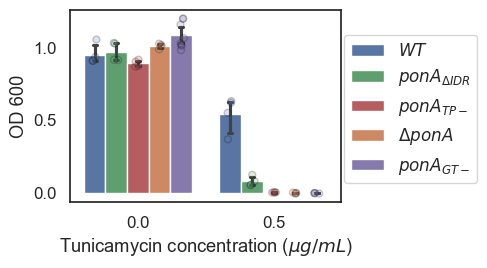

<Figure size 640x480 with 0 Axes>

In [140]:
fig=plt.figure(figsize=[3.5,2.5])
sns.set(font_scale=1.1)
sns.set_style('white')
colors=sns.color_palette()
pal=[colors[0],colors[2],colors[3],colors[1],colors[4]]
sns.barplot(data=temp_df,x='Tunicamycin conc',y='Maximum OD',hue='Celltype', hue_order=temp_hue,capsize=0.15,palette=pal,errorbar='ci')
sns.stripplot(x='Tunicamycin conc',y='Maximum OD',dodge=True,data=temp_df,hue='Celltype',palette=pal, hue_order=temp_hue,color='k',edgecolor='black',linewidth=1,alpha=0.2,legend=False)
# sns.stripplot(data=df,x='Tunicamycin conc',y='Maximum OD',hue='Celltype', hue_order=temp_hue,palette=pal)
ax=plt.gca()
# handles, labels = ax.get_legend_handles_labels()

plt.legend(loc=[1.01,0.1])
plt.ylabel('OD 600')
plt.xlabel(r'Tunicamycin concentration ($\mu g/mL$)')
xtick_locs,vals=plt.xticks()
# plt.xticks(rotation = 50)
plt.xticks(ticks=xtick_locs,labels=[0.0, 0.5])

fig.savefig('./outputs'+expt_id+expt_id+'_OD_plot_paper_compiled.pdf',bbox_inches='tight')
plt.show()
plt.clf()

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_41671/74521994.py:6: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.barplot(data=temp_df,x='Tunicamycin conc',y='Maximum OD',hue='Celltype', hue_order=temp_hue,capsize=0.15,palette=pal)
/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_41671/74521994.py:7: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.stripplot(x='Tunicamycin conc',y='Maximum OD',dodge=True,data=temp_df,hue='Celltype',palette=pal, hue_order=temp_hue,color='k',edgecolor='black',linewidth=1,alpha=0.2,legend=False)


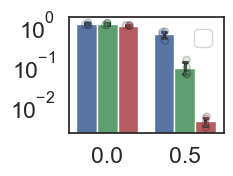

In [141]:
temp_hue = [r'$WT$',r'$ponA_{\Delta IDR}$',r'$ponA_{TP-}$']
fig=plt.figure(figsize=[2,1.5])
sns.set(font_scale=1.5)
sns.set_style('white')
colors=sns.color_palette()
sns.barplot(data=temp_df,x='Tunicamycin conc',y='Maximum OD',hue='Celltype', hue_order=temp_hue,capsize=0.15,palette=pal)
sns.stripplot(x='Tunicamycin conc',y='Maximum OD',dodge=True,data=temp_df,hue='Celltype',palette=pal, hue_order=temp_hue,color='k',edgecolor='black',linewidth=1,alpha=0.2,legend=False)
ax=plt.gca()

plt.ylabel('')
plt.xlabel('')
xtick_locs,vals=plt.xticks()
# plt.xticks(rotation = 50)
plt.xticks(ticks=xtick_locs,labels=[0.0, 0.5])
ax.set_yscale('log')
# plt.ylim(ymin=0.005,ymax=1.2)
plt.legend('')
fig.savefig('./outputs'+expt_id+expt_id+'_OD_plot_paper_compiled_log.pdf',bbox_inches='tight')

In [142]:
temp_celltypes=list(temp_df.Celltype.unique())
pv=0.01 # p value
for conc in df['Tunicamycin conc'].unique():
    for celltype in temp_celltypes:
        for celltype1 in temp_celltypes[temp_celltypes.index(celltype)+1:]:
            print(conc, celltype, celltype1)
            x1=df[(df['Tunicamycin conc']==conc)*df.Celltype==celltype]['Maximum OD']
            x2=df[(df['Tunicamycin conc']==conc)*df.Celltype==celltype1]['Maximum OD']
            out_vals=scipy.stats.ttest_ind(x1,x2)
            if out_vals[1]<pv:
                print(out_vals)
            else:
                print('not significant')

0.0 $ponA_{\Delta IDR}$ $ponA_{GT-}$
not significant
0.0 $ponA_{\Delta IDR}$ $WT$
not significant
0.0 $ponA_{\Delta IDR}$ $\Delta ponA$
not significant
0.0 $ponA_{\Delta IDR}$ $ponA_{TP-}$
not significant
0.0 $ponA_{GT-}$ $WT$
not significant
0.0 $ponA_{GT-}$ $\Delta ponA$
not significant
0.0 $ponA_{GT-}$ $ponA_{TP-}$
not significant
0.0 $WT$ $\Delta ponA$
not significant
0.0 $WT$ $ponA_{TP-}$
not significant
0.0 $\Delta ponA$ $ponA_{TP-}$
Ttest_indResult(statistic=8.600734345680836, pvalue=0.0001358606706031365)
0.5 $ponA_{\Delta IDR}$ $ponA_{GT-}$
Ttest_indResult(statistic=7.3581830655528995, pvalue=2.4304147008775758e-05)
0.5 $ponA_{\Delta IDR}$ $WT$
Ttest_indResult(statistic=-7.390356085773367, pvalue=0.0003150151085713439)
0.5 $ponA_{\Delta IDR}$ $\Delta ponA$
Ttest_indResult(statistic=4.879049696865774, pvalue=0.00276888898316753)
0.5 $ponA_{\Delta IDR}$ $ponA_{TP-}$
Ttest_indResult(statistic=4.611934454053634, pvalue=0.003646053517009701)
0.5 $ponA_{GT-}$ $WT$
Ttest_indResult(st

One-way anova test for means

In [143]:
outs_anova=[]
temp_hue = [r'$WT$',r'$ponA_{\Delta IDR}$',r'$ponA_{TP-}$',r'$\Delta ponA$', r'$ponA_{GT-}$']
print(temp_hue)
for conc in df['Tunicamycin conc'].unique():
    samples=[np.asarray(df[(df['Tunicamycin conc']==conc)*df.Celltype==temp_hue[i0]]['Maximum OD']) for i0 in range(len(temp_hue))]
    outs_anova.append(scipy.stats.f_oneway(samples[0],samples[1],samples[2],samples[3],samples[4], axis=0))
    print(conc,outs_anova[-1])
    if outs_anova[-1][1]<0.01:
        print('Tukey:', scipy.stats.tukey_hsd(samples[0],samples[1],samples[2],samples[3],samples[4]))
        

['$WT$', '$ponA_{\\Delta IDR}$', '$ponA_{TP-}$', '$\\Delta ponA$', '$ponA_{GT-}$']
0.0 F_onewayResult(statistic=0.1367996203179174, pvalue=0.9672549866949642)
0.5 F_onewayResult(statistic=94.94286453103375, pvalue=2.77544440814328e-12)
Tukey: Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.464     0.000     0.358     0.570
 (0 - 2)      0.539     0.000     0.433     0.645
 (0 - 3)      0.544     0.000     0.438     0.650
 (0 - 4)      0.545     0.000     0.453     0.637
 (1 - 0)     -0.464     0.000    -0.570    -0.358
 (1 - 2)      0.075     0.250    -0.031     0.181
 (1 - 3)      0.080     0.202    -0.027     0.186
 (1 - 4)      0.081     0.104    -0.011     0.172
 (2 - 0)     -0.539     0.000    -0.645    -0.433
 (2 - 1)     -0.075     0.250    -0.181     0.031
 (2 - 3)      0.005     1.000    -0.102     0.111
 (2 - 4)      0.005     1.000    -0.087     0.097
 (3 - 0)     -0.544     0.000    -0.650